<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/week%204/alfagift_bagofwords.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Alfagift Google App Review - Bag of Words**

Berikut adalah penjelasan rinci mengenai setiap langkah yang telah dilakukan dalam analisis ulasan aplikasi Alfagift:

## **1. Pemuatan Data dan Pembersihan Awal**
Tahap ini melibatkan pemuatan dataset ulasan aplikasi Alfagift dari file CSV. Setelah data dimuat ke dalam DataFrame Pandas, kolom 'content' yang berisi teks ulasan diubah menjadi tipe data string untuk memastikan konsistensi dan kemudian semua teks diubah menjadi huruf kecil (`lowercase`) untuk menyeragamkan data dan memfasilitasi analisis selanjutnya.

In [2]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df_alfagiftrev = pd.read_csv(list(uploaded.keys())[0])
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)
df_alfagiftrev['content'] = df_alfagiftrev['content'].str.lower()
df_alfagiftrev.head()

Saving df_alfagiftrev_preprocessing (5).csv to df_alfagiftrev_preprocessing (5).csv


,content,content_cleaned,score,sentiment_polarity,review_length,sentiment_subjective,sentiment_rating,at,word_tokenize,wordCount,wordCount_after_stopwords
0,parah sesi anda telah selesai ngapain coba kel...,parah sesi selesai ngapain coba keluara gunaka,1,0.0,77,0.0,Negative,2026-03-30 13:39:27,"['parah', 'sesi', 'selesai', 'ngapain', 'coba'...",13,7
1,tolong pihak alfamart sediakan jual rokok,tolong alfamart sediakan jual rokok,2,0.0,41,0.0,Negative,2026-03-30 13:33:37,"['tolong', 'alfamart', 'sediakan', 'jual', 'ro...",6,5
2,ini gaada menu cancel orderan kah,gaada menu cancel orderan kah,3,0.0,33,0.0,Neutral,2026-03-30 13:11:09,"['gaada', 'menu', 'cancel', 'orderan', 'kah']",6,5
3,percuma ada chat aplikasi kalo gapernah dibaca...,chat aplikasi gapernah dibaca mending klik idm...,1,0.0,192,0.0,Negative,2026-03-30 12:57:09,"['chat', 'aplikasi', 'gapernah', 'dibaca', 'me...",35,24
4,udah nyaman eh alfamart nya pindah jadi jauh s...,udah nyaman eh alfamart pindah 1 jam pembayara...,2,0.0,89,0.0,Negative,2026-03-30 12:46:39,"['udah', 'nyaman', 'eh', 'alfamart', 'pindah',...",16,11


## **2. Normalisasi Teks (Menghapus Karakter Berulang)**
Pada tahap ini, fungsi `normalize_repeated_chars` diterapkan untuk membersihkan teks ulasan dari karakter yang berulang lebih dari dua kali (misalnya, 'baaaaik' menjadi 'baaak'). Ini membantu mengurangi kebisingan data dan memastikan bahwa variasi penulisan tidak terlalu memengaruhi analisis frekuensi kata. Langkah ini juga mencakup penanganan nilai yang hilang (`NaN`) dengan mengisi string kosong sebelum normalisasi.

In [7]:
import re
def normalize_repeated_chars(text):
    # Menghapus karakter yang berulang lebih dari 2 kali (misal: 'bbb' menjadi 'bb')
    # Menggunakan backreference \1 untuk mendeteksi karakter yang sama
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

df_alfagiftrev['content_clean'] = df_alfagiftrev['content_cleaned'].fillna('').astype(str).apply(normalize_repeated_chars)

## **3. Ekstraksi Fitur Sentimen Berbasis Regex**
Dengan menggunakan ekspresi reguler (regex), kami mencari kata kunci tertentu yang mengindikasikan sentimen positif (misalnya, 'membantu', 'promo', 'bagus') dan negatif (misalnya, 'kecewa', 'susah', 'lemot') dalam ulasan. Dua kolom baru, `feat_positive` dan `feat_negative`, dibuat untuk menandai apakah ulasan mengandung kata kunci sentimen positif atau negatif.

In [8]:
import pandas as pd
import re

def extract_sentiment_regex(df):
    # Mengatasi nilai NaN agar tidak error saat diproses regex
    content_clean_series = df['content_cleaned'].fillna('').astype(str)

    # --- REGEX UNTUK SENTIMEN POSITIF ---
    # Mencari kata-kata pujian, kepuasan, dan efisiensi
    pos_pattern = re.compile(
        r'membantu|promo|cepat|mudah|bagus|mantap|gratis|memudahkan|terbaik|puas|good|menarik|ramah|oke|keren|luar biasa',
        re.IGNORECASE
    )

    # --- REGEX UNTUK SENTIMEN NEGATIF ---
    # Mencari kata-kata keluhan, kekecewaan, dan masalah teknis
    neg_pattern = re.compile(
        r'kecewa|susah|lemot|error|buruk|parah|jelek|mahal|gagal|rugi|penipu|batal|cancel|sulit|lambat|mengecewakan|tolong|parah',
        re.IGNORECASE
    )

    # Membuat Fitur Baru
    # Fitur Positive: 1 jika mengandung kata positif, 0 jika tidak
    df['feat_positive'] = content_clean_series.apply(lambda x: 1 if pos_pattern.search(x) else 0)

    # Fitur Negative: 1 jika mengandung kata negatif, 0 jika tidak
    df['feat_negative'] = content_clean_series.apply(lambda x: 1 if neg_pattern.search(x) else 0)

    return df

# 2. Menjalankan fungsi pada df_alfagiftrev
df_alfagiftrev = extract_sentiment_regex(df_alfagiftrev)

# 3. Improvisasi: Menampilkan Ringkasan Hasil
print("Ringkasan Deteksi Keyword:")
print(f"Total Ulasan dengan Keyword Positif: {df_alfagiftrev['feat_positive'].sum()}")
print(f"Total Ulasan dengan Keyword Negatif: {df_alfagiftrev['feat_negative'].sum()}")

# Menampilkan contoh hasil
cols_to_show = ['content_cleaned', 'feat_positive', 'feat_negative']
display(df_alfagiftrev[cols_to_show].head(10))

Ringkasan Deteksi Keyword:
Total Ulasan dengan Keyword Positif: 97927
Total Ulasan dengan Keyword Negatif: 15656


,content_cleaned,feat_positive,feat_negative
0,parah sesi selesai ngapain coba keluara gunaka,0,1
1,tolong alfamart sediakan jual rokok,0,1
2,gaada menu cancel orderan kah,0,1
3,chat aplikasi gapernah dibaca mending klik idm...,0,0
4,udah nyaman eh alfamart pindah 1 jam pembayara...,0,0
5,bagus,1,0
6,bintang bicara,0,0
7,customer service pelayanan buruk,0,1
8,kerenn,1,0
9,barang diterima nyasar disimpan dimana alfanya...,0,1


## **4. Visualisasi Distribusi Sentimen**
Setelah mengekstrak fitur sentimen, kami memvisualisasikan jumlah ulasan yang mengandung kata kunci positif dan negatif menggunakan *bar plot*. Visualisasi ini memberikan gambaran cepat tentang proporsi ulasan yang cenderung positif atau negatif berdasarkan deteksi kata kunci.

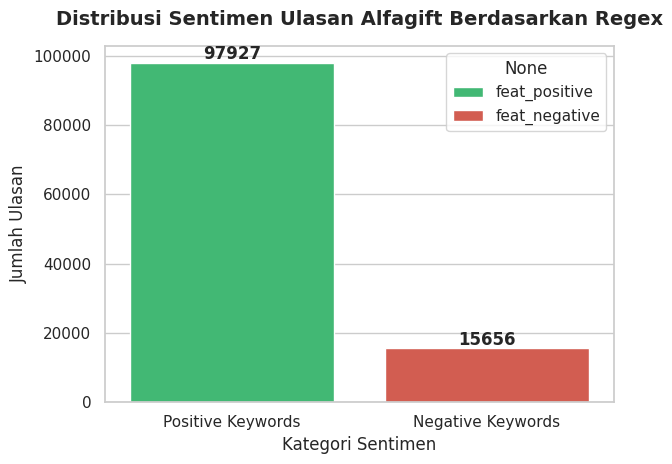

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menentukan fitur baru yang ingin divisualisasikan
# Sesuai dengan hasil regex: Positive vs Negative
features = ['feat_positive', 'feat_negative']
counts = df_alfagiftrev[features].sum()

# 2. Membuat visualisasi
sns.set_theme(style="whitegrid") # Menambah grid agar lebih profesional
plt.clf() # Membersihkan plot sebelumnya jika ada

# Menggunakan palette kustom: Hijau (Positive) dan Merah (Negative)
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette=['#2ecc71', '#e74c3c'],
    legend=True # Menampilkan legend untuk keterangan warna
)

# 3. Formating Judul dan Label
plt.title('Distribusi Sentimen Ulasan Alfagift Berdasarkan Regex', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xlabel('Kategori Sentimen', fontsize=12)

# Mengganti label tick x agar lebih representatif
plt.xticks(ticks=[0, 1], labels=['Positive Keywords', 'Negative Keywords'], fontsize=11)

# 4. Menambahkan label angka di atas batang secara presisi
for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values) * 0.01), str(int(v)), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## **5. Analisis Bag of Words (BoW) Manual**
Pada tahap ini, semua teks ulasan digabungkan menjadi satu string besar, kemudian dipecah menjadi token-token (kata-kata) individual. Frekuensi kemunculan setiap kata dihitung secara manual menggunakan `collections.Counter`. Hasilnya adalah daftar kata-kata paling sering muncul, memberikan wawasan awal tentang topik dominan dalam ulasan.

In [10]:
from collections import Counter
import re

# gabungkan semua teks
all_text = ' '.join(df_alfagiftrev['content_cleaned'].astype(str))

# tokenisasi sederhana
tokens = re.findall(r'\b\w+\b', all_text.lower())

# hitung frekuensi
bow_manual = Counter(tokens)

# tampilkan 20 kata paling sering
bow_manual.most_common(20)

[('belanja', 34666),
 ('aplikasi', 30949),
 ('alfagift', 28003),
 ('membantu', 17653),
 ('promo', 17078),
 ('bagus', 14348),
 ('cepat', 14324),
 ('banget', 13709),
 ('mudah', 13423),
 ('pengiriman', 12917),
 ('alfamart', 11874),
 ('mantap', 10026),
 ('kirim', 9505),
 ('barang', 9374),
 ('rumah', 9149),
 ('ongkos', 7779),
 ('gratis', 7477),
 ('berbelanja', 6796),
 ('ya', 6623),
 ('alfa', 6185)]

## **6. Pembentukan Bag of Words dengan CountVectorizer**
`CountVectorizer` dari pustaka `sklearn` digunakan untuk mengubah koleksi dokumen teks menjadi matriks jumlah token (Bag of Words). Kami mengonfigurasi *vectorizer* untuk memilih 1000 kata paling penting, mempertimbangkan unigram dan bigram (pasangan kata), serta mengabaikan kata-kata yang muncul di kurang dari 5 dokumen atau lebih dari 80% dokumen untuk menghilangkan kata-kata yang terlalu jarang atau terlalu umum.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# inisialisasi vectorizer
vectorizer = CountVectorizer(
    max_features=1000,     # ambil 1000 kata paling penting
    ngram_range=(1,2),     # unigram + bigram
    min_df=5,              # minimal muncul di 5 dokumen
    max_df=0.8             # buang kata terlalu umum
)

# fit dan transform
X = vectorizer.fit_transform(df_alfagiftrev['content_cleaned'].astype(str))

# ubah ke dataframe
bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df.head()

,10,100,11,12,15,2x,30,30 menit,abis,ad,...,voucer,voucher,voucher belanja,vouchernya,wa,wifi,wow,ya,ya alfagift,yaa
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **7. Analisis Frekuensi Kata**
Setelah matriks Bag of Words terbentuk, kami menghitung total kemunculan setiap kata di seluruh korpus. Hasilnya disajikan dalam DataFrame yang menampilkan kata-kata dan frekuensinya, diurutkan dari yang paling sering muncul. Ini membantu mengidentifikasi kata kunci utama dalam ulasan.

In [12]:
import numpy as np

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'frequency': word_counts
}).sort_values(by='frequency', ascending=False)

word_freq.head(20)

,word,frequency
137,belanja,34666
68,aplikasi,30949
24,alfagift,28003
564,membantu,17653
776,promo,17078
91,bagus,14348
227,cepat,14324
102,banget,13709
619,mudah,13423
727,pengiriman,12917


## **8. Visualisasi Frekuensi Kata Teratas**
20 kata paling sering muncul divisualisasikan menggunakan *horizontal bar plot*. Visualisasi ini memudahkan untuk melihat secara sekilas kata-kata apa saja yang paling banyak digunakan oleh pengguna dalam ulasan mereka.

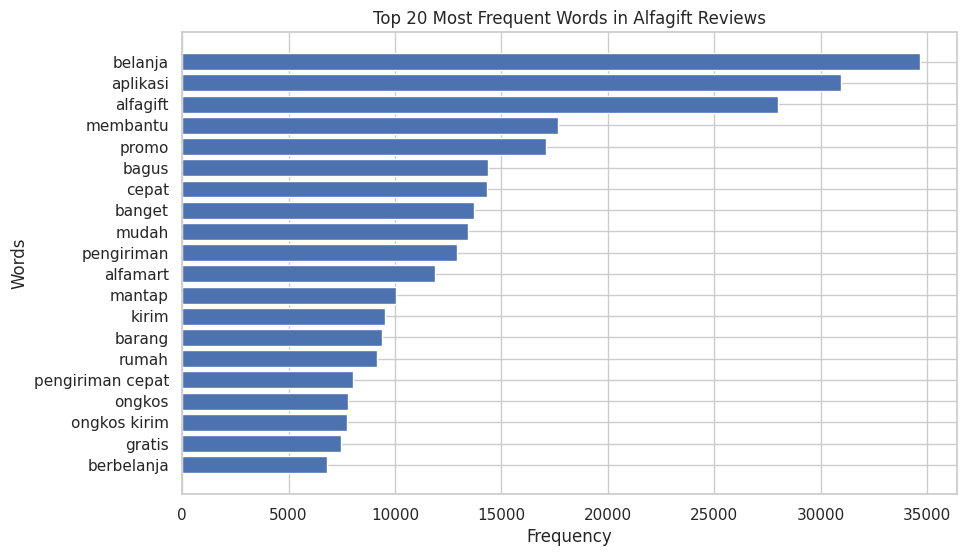

In [13]:
import matplotlib.pyplot as plt

top_n = 20
top_words = word_freq.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_words['word'], top_words['frequency'])
plt.gca().invert_yaxis()
plt.title('Top 20 Most Frequent Words in Alfagift Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

## **9. Analisis Bigram**
Mirip dengan analisis kata tunggal, tahap ini berfokus pada pasangan kata (bigram). `CountVectorizer` dikonfigurasi khusus untuk mendeteksi bigram, dengan batasan `min_df=5` dan `max_features=20` untuk mendapatkan 20 bigram paling sering yang muncul setidaknya di 5 dokumen. Ini membantu mengidentifikasi frasa atau kombinasi kata yang sering digunakan bersama.

In [14]:
vectorizer_bigram = CountVectorizer(
    ngram_range=(2,2),
    min_df=5,
    max_features=20
)

# Ensure no NaN values are present in the 'content_cleaned' column
X_bigram = vectorizer_bigram.fit_transform(df_alfagiftrev['content_cleaned'].fillna(''))

bigram_counts = np.sum(X_bigram.toarray(), axis=0)

bigram_df = pd.DataFrame({
    'bigram': vectorizer_bigram.get_feature_names_out(),
    'frequency': bigram_counts
}).sort_values(by='frequency', ascending=False)

bigram_df

,bigram,frequency
16,pengiriman cepat,8013
15,ongkos kirim,7754
12,gratis ongkos,5678
9,belanja mudah,3553
3,aplikasi membantu,3509
7,belanja alfagift,3062
1,aplikasi alfagift,3057
10,belanja online,2433
2,aplikasi bagus,2381
0,alfa gift,2264


## **10. Visualisasi Bigram Teratas**
20 bigram yang paling sering muncul divisualisasikan menggunakan *horizontal bar plot*. Visualisasi ini melengkapi analisis kata tunggal dengan menunjukkan konteks yang lebih kaya dari ulasan, mengungkapkan frasa kunci yang memberikan gambaran lebih mendalam tentang sentimen atau masalah yang sering dibicarakan pengguna.

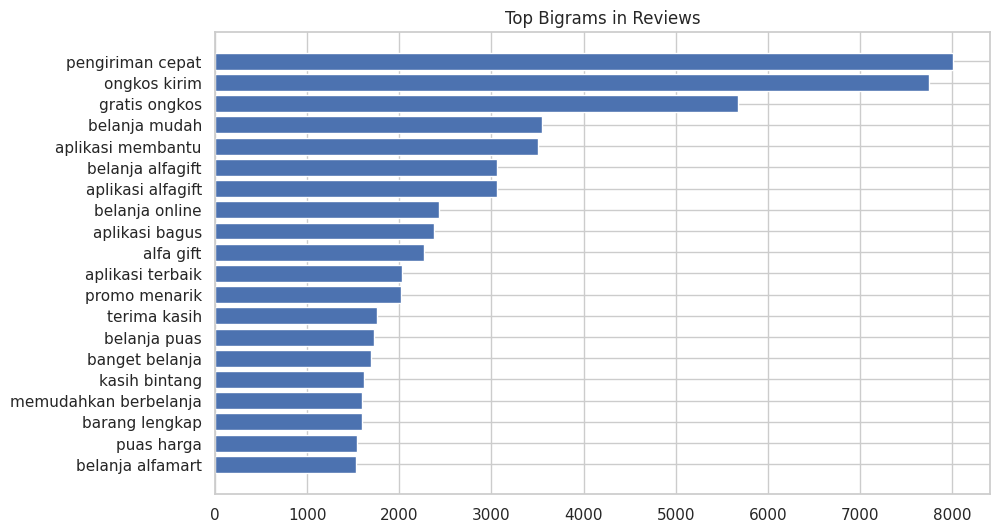

In [15]:
plt.figure(figsize=(10,6))
plt.barh(bigram_df['bigram'], bigram_df['frequency'])
plt.gca().invert_yaxis()
plt.title('Top Bigrams in Reviews')
plt.show()

In [16]:
df_alfagiftrev.to_csv('alfagift_bow.csv', index=False)
print('File saved successfully as alfagift_reviews_processed.csv')

File saved successfully as alfagift_reviews_processed.csv
